Training Linear Model...
Training ReLU Model...


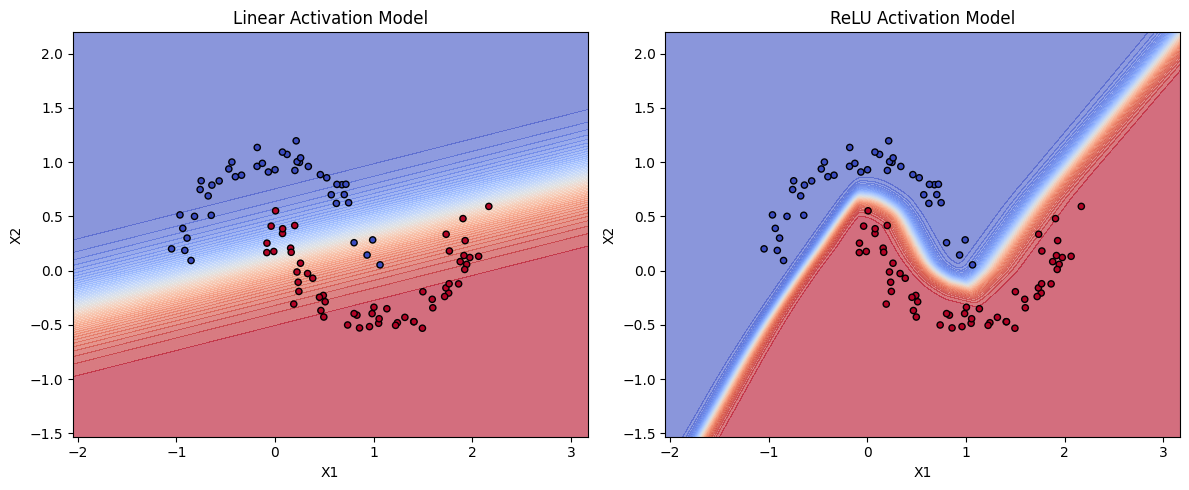


FINAL COMPARISON
Linear Model Accuracy : 0.8600
ReLU Model Accuracy   : 1.0000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


X, y = make_moons(n_samples=500, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model_linear = Sequential([
    Dense(128, input_dim=2, activation='linear'),
    Dense(128, activation='linear'),
    Dense(1, activation='sigmoid')
])

model_linear.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Training Linear Model...")
history_linear = model_linear.fit(
    X_train, y_train,
    epochs=50,
    verbose=0
)

loss_linear, acc_linear = model_linear.evaluate(X_test, y_test, verbose=0)


model_relu = Sequential([
    Dense(128, input_dim=2, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_relu.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Training ReLU Model...")
history_relu = model_relu.fit(
    X_train, y_train,
    epochs=50,
    verbose=0
)

loss_relu, acc_relu = model_relu.evaluate(X_test, y_test, verbose=0)


def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0)
    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, levels=50, cmap='coolwarm', alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20)

    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(model_linear, X_test, y_test, "Linear Activation Model")

plt.subplot(1, 2, 2)
plot_decision_boundary(model_relu, X_test, y_test, "ReLU Activation Model")

plt.tight_layout()
plt.show()


print("\n==============================")
print("FINAL COMPARISON")
print("==============================")

print(f"Linear Model Accuracy : {acc_linear:.4f}")
print(f"ReLU Model Accuracy   : {acc_relu:.4f}")